In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from pathlib import Path

c:\Users\nasta\anaconda3\envs\ssp_metamodel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_summary_results_run_sisepuede_run_2025-08-10t10;29;30.545790")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [3]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.2_narrative_profiles_new_ed.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings,human_health
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.199758,0.969220,59.720047,3553.270010,7.915055e+08,1.484591e+10,-42.336438,-33.250075,5.511622,7.444526
1,0.355127,0.388826,0.495092,0.282101,0.198981,0.620631,0.428909,0.192468,0.035291,0.729170,...,0.725034,0.902345,30.972144,3028.607700,8.012644e+08,1.451503e+10,-21.656242,-19.779789,6.947874,8.685293
2,0.970473,0.436334,0.243523,0.227546,0.467160,0.102438,0.605842,0.087344,0.997124,0.240382,...,0.208350,0.175365,92.551550,4127.536839,9.337928e+08,1.274256e+10,-40.157702,-36.090181,6.355524,8.469585
3,0.605323,0.210722,0.661197,0.823838,0.003365,0.990644,0.114855,0.215559,0.363979,0.854653,...,0.227383,0.113647,11.015231,2668.240547,8.241354e+08,1.235943e+10,-53.155978,-6.495959,7.441004,8.909666
4,0.247035,0.704965,0.523551,0.535350,0.345173,0.482609,0.894310,0.862094,0.236449,0.329243,...,0.947292,0.764492,41.876734,3343.173022,7.863009e+08,1.512143e+10,-77.798140,-42.784060,6.063635,6.719518


## EDA

In [4]:
edau = EDAUtils()

In [5]:
target_cols = [col for col in training_df.columns if "emission" in col] + ['production_total']+['production_cost_total']+["technical_cost"]+["air_pollution"]+["consumer_savings"]+["human_health"]
target_cols

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'consumer_savings',
 'human_health']

In [6]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_frac_enfu_transmission_loss_fuel_electricity',
 'group_6_nemomod_en',
 'group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis',
 'group_8_frac_fgtv_reduction_in_fugitive_leaks',
 'group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_10_efficfactor_enfu_industrial_energy_fuel',
 'group_11_scalar_inen_energy_demand',
 'group_12_frac_inen_energy',
 'group_13_frac_ippu_cement_clinker',
 'group_14_ef_ippu_tonne_c',
 'group_15_ef_ippu_tonne_n2o_per',
 'group_16_ef_ippu_tonne_c',
 'group_17_pij_lndu',
 'group_18_frac_lndu_improved_pastures',
 'group_19_lndu_reallocation_factor',
 'group_20_gasrf_lsmm_biogas_anaerobic',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm',
 'group_23_frac_lvst_mm_chickens',
 'group_24_ef_lvst_entferm',
 'group_25_frac_gnrl_eating_red_meat

In [7]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings,human_health
count,1988.000000,1988.000000,1.988000e+03,1.988000e+03,1.988000e+03,1988.000000,1988.000000,1988.000000
mean,104.749732,4266.429562,8.424183e+08,3.282049e+13,-2.349160e+08,-4438.484082,6.414345,7.574534
std,218.886143,3463.127200,2.394798e+08,1.275259e+14,1.116284e+09,17200.403901,0.974304,0.779816
min,-16.071475,1726.857850,0.000000e+00,1.108367e+10,-5.640888e+09,-86029.149518,4.046766,6.226977
25%,34.913576,3145.931248,7.966226e+08,1.263278e+10,-9.072551e+01,-32.964900,5.674039,6.898570
50%,53.564501,3457.359997,8.861764e+08,1.328170e+10,-5.024862e+01,-24.494872,6.398145,7.578381
75%,72.663746,3798.960870,9.697443e+08,1.414412e+10,-2.025542e+01,-17.540627,7.134508,8.249216
max,1524.495400,26664.633567,1.180392e+09,6.064395e+14,4.216979e+02,7.441070,9.104423,8.921161


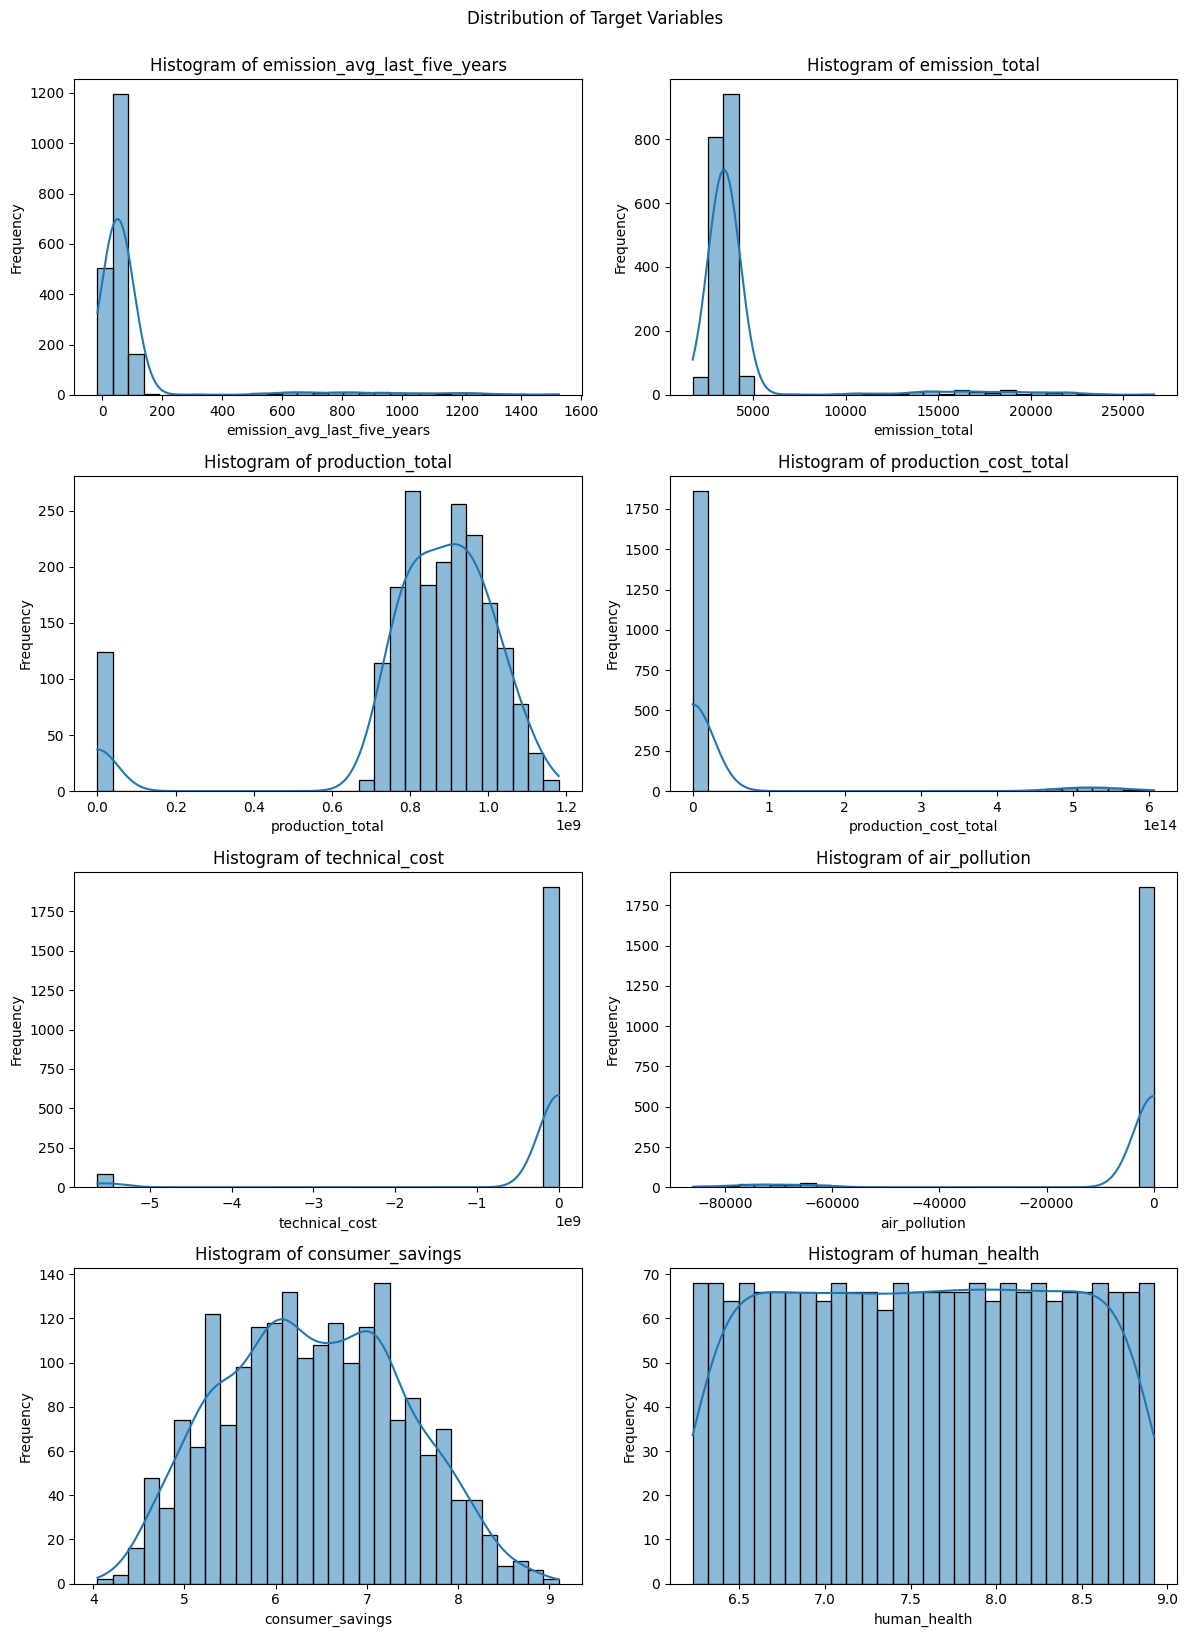

In [8]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [10]:
edau.get_target_var_corr(training_df, "emission_total")
edau.get_target_var_corr(training_df, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df, "production_total")
edau.get_target_var_corr(training_df, "production_cost_total")
edau.get_target_var_corr(training_df, "technical_cost")
edau.get_target_var_corr(training_df, "air_pollution")
edau.get_target_var_corr(training_df, "consumer_savings")
edau.get_target_var_corr(training_df, "human_health")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9894
production_cost_total          : 0.9555
air_pollution                  : 0.9494
production_total               : 0.8359
technical_cost                 : 0.7751
group_6_nemomod_en             : 0.1412
group_44_frac_waso             : 0.1016


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9894
production_cost_total          : 0.9471
air_pollution                  : 0.9437
production_total               : 0.8301
technical_cost                 : 0.7770
group_6_nemomod_en             : 0.1265


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
production_total      

In [ ]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [11]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 6.54, 'emission_total': 6.84, 'production_total': 6.24, 'production_cost_total': 6.24, 'technical_cost': 7.04, 'air_pollution': 6.44}


## Data Cleaning

In [12]:
dcu = DataCleaningUtils()

In [13]:
training_df.shape

(1988, 66)

In [ ]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [ ]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [14]:
training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (1844, 66)


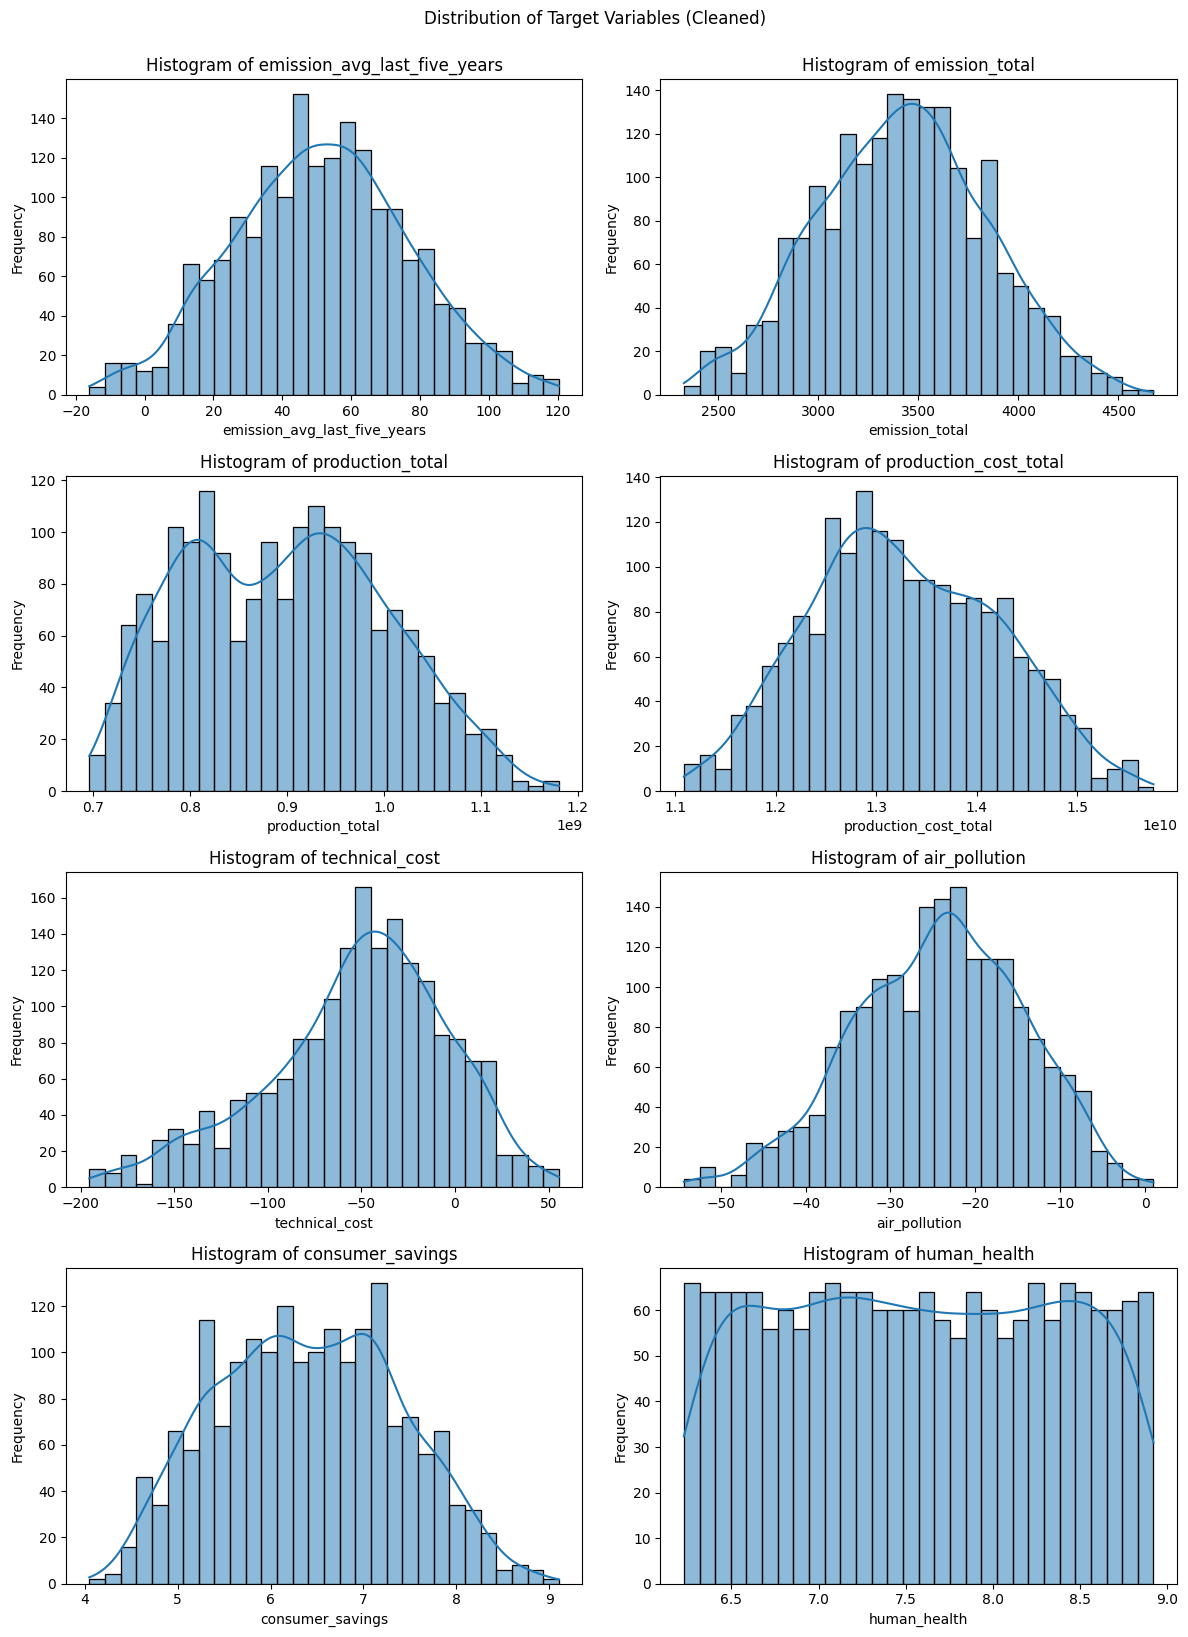

In [15]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [16]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'air_pollution': 0.11}


In [18]:
edau.get_target_var_corr(training_df, "emission_total")
edau.get_target_var_corr(training_df, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df, "production_total")
edau.get_target_var_corr(training_df, "production_cost_total")
edau.get_target_var_corr(training_df, "technical_cost")
edau.get_target_var_corr(training_df, "air_pollution")
edau.get_target_var_corr(training_df, "consumer_savings")
edau.get_target_var_corr(training_df, "human_health")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9894
production_cost_total          : 0.9555
air_pollution                  : 0.9494
production_total               : 0.8359
technical_cost                 : 0.7751
group_6_nemomod_en             : 0.1412
group_44_frac_waso             : 0.1016


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9894
production_cost_total          : 0.9471
air_pollution                  : 0.9437
production_total               : 0.8301
technical_cost                 : 0.7770
group_6_nemomod_en             : 0.1265


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
production_total      

In [ ]:
training_df_cleaned[target_cols].describe()

In [ ]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [ ]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [ ]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [ ]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [ ]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training


=== XGB ===
emission_total                
  Train → MAE: 0.1232, RMSE: 0.1914, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 31.0946, RMSE: 79.2472, R²: 0.9672, SMAPE: 0.9%
emission_avg_last_five_years  
  Train → MAE: 0.0092, RMSE: 0.0142, R²: 1.0000, SMAPE: 0.1%
   Test → MAE: 2.2500, RMSE: 5.7018, R²: 0.9526, SMAPE: 4.7%
production_total              
  Train → MAE: 23610.7606, RMSE: 36858.9773, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 2714119.3065, RMSE: 8329107.4671, R²: 0.9931, SMAPE: 0.3%
production_cost_total         
  Train → MAE: 210792.2973, RMSE: 327954.6362, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 20318800.1509, RMSE: 54596318.4087, R²: 0.9966, SMAPE: 0.2%
technical_cost                
  Train → MAE: 0.0322, RMSE: 0.0489, R²: 1.0000, SMAPE: 0.4%
   Test → MAE: 3.8852, RMSE: 10.1342, R²: 0.9577, SMAPE: 9.3%
air_pollution                 
  Train → MAE: 0.0051, RMSE: 0.0077, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 0.5975, RMSE: 1.5034, R²: 0.9773, SMAPE: 2.5%
consumer_savings      

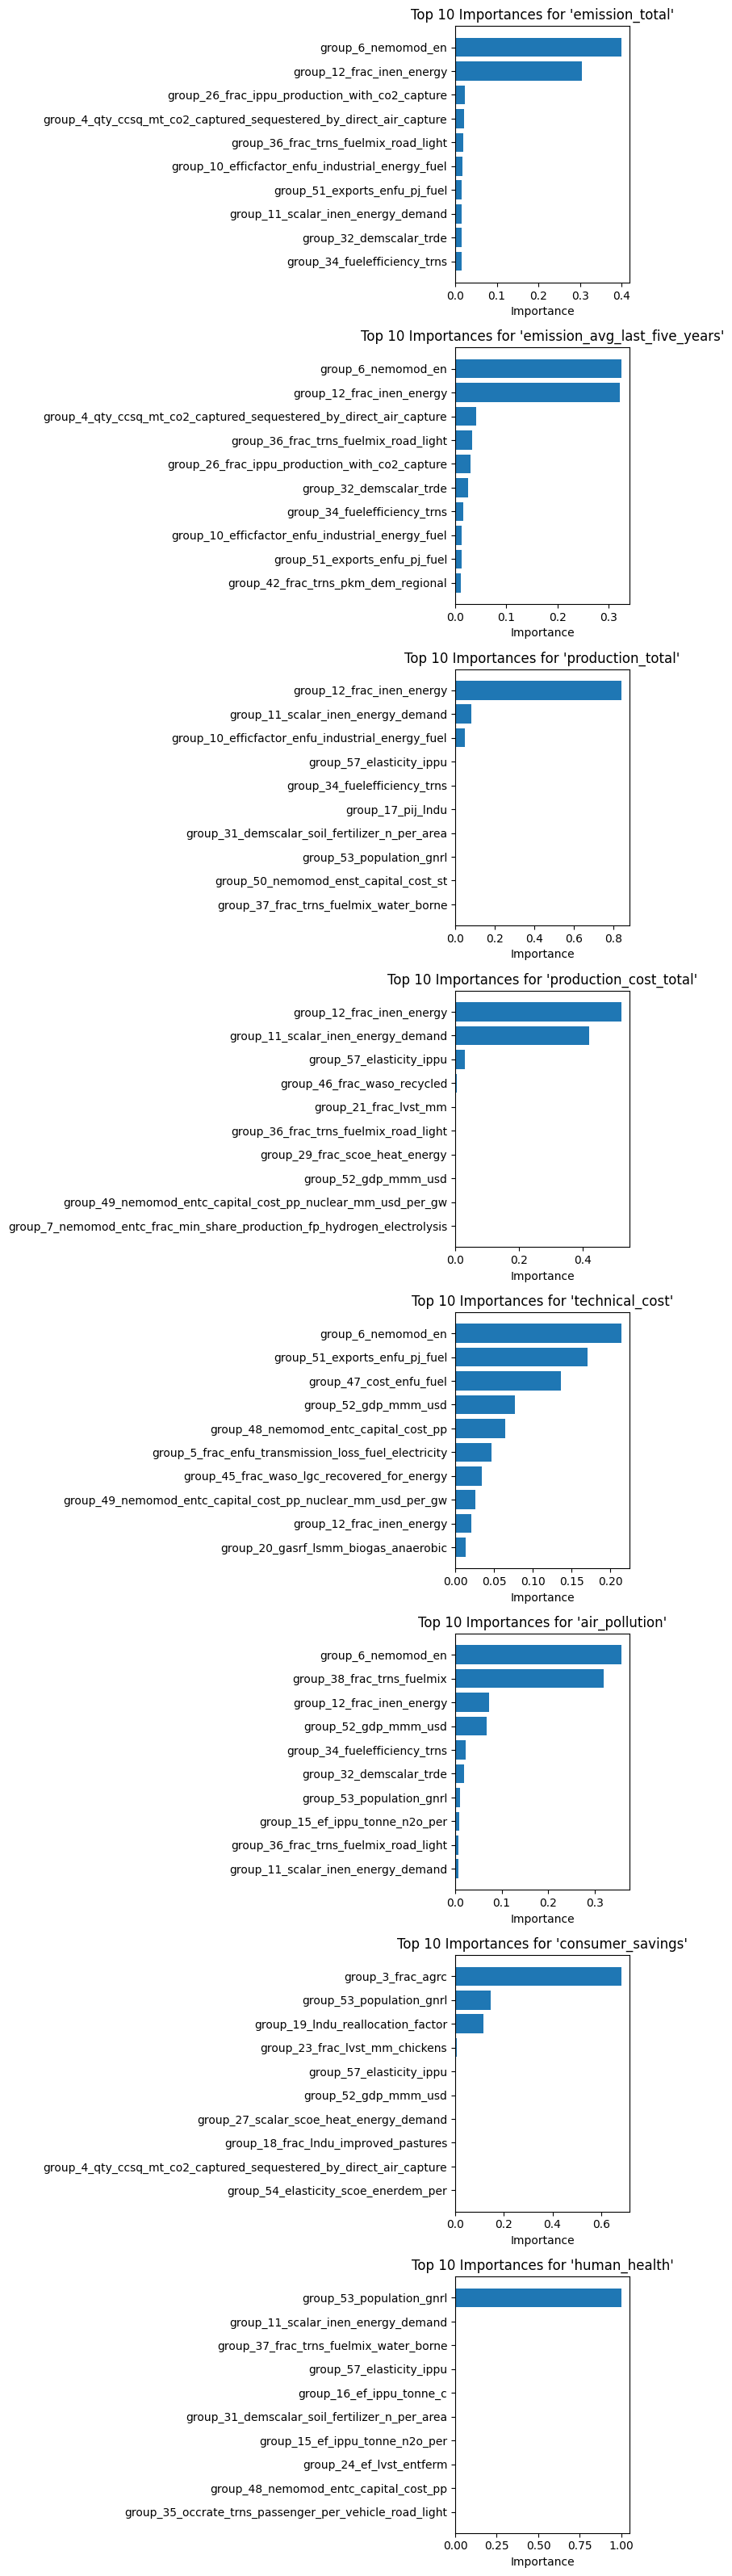

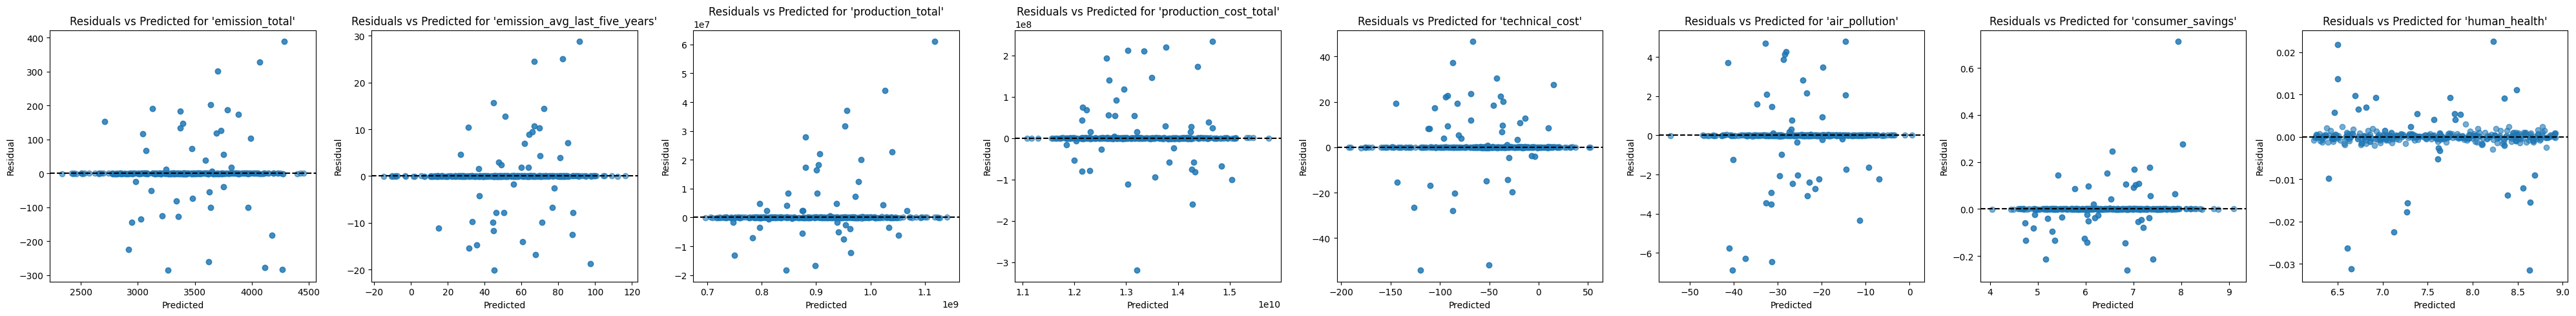

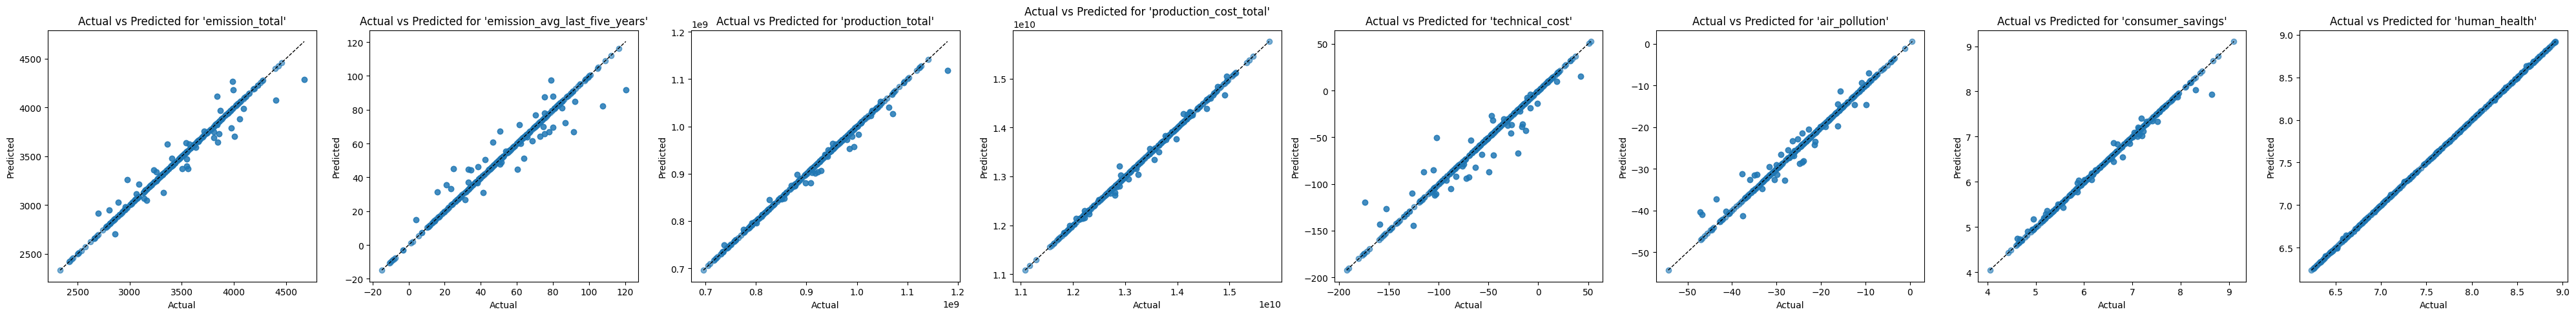

In [19]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["emission_total", "emission_avg_last_five_years","production_total", "production_cost_total",  "technical_cost", "air_pollution", "consumer_savings","human_health"])
mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [20]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings,human_health
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.199758,0.969220,59.720047,3553.270010,7.915055e+08,1.484591e+10,-42.336438,-33.250075,5.511622,7.444526
1,0.355127,0.388826,0.495092,0.282101,0.198981,0.620631,0.428909,0.192468,0.035291,0.729170,...,0.725034,0.902345,30.972144,3028.607700,8.012644e+08,1.451503e+10,-21.656242,-19.779789,6.947874,8.685293
2,0.970473,0.436334,0.243523,0.227546,0.467160,0.102438,0.605842,0.087344,0.997124,0.240382,...,0.208350,0.175365,92.551550,4127.536839,9.337928e+08,1.274256e+10,-40.157702,-36.090181,6.355524,8.469585
3,0.605323,0.210722,0.661197,0.823838,0.003365,0.990644,0.114855,0.215559,0.363979,0.854653,...,0.227383,0.113647,11.015231,2668.240547,8.241354e+08,1.235943e+10,-53.155978,-6.495959,7.441004,8.909666
4,0.247035,0.704965,0.523551,0.535350,0.345173,0.482609,0.894310,0.862094,0.236449,0.329243,...,0.947292,0.764492,41.876734,3343.173022,7.863009e+08,1.512143e+10,-77.798140,-42.784060,6.063635,6.719518


In [21]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(["emission_total", "emission_avg_last_five_years","production_total", "production_cost_total",  "technical_cost", "air_pollution", "consumer_savings", "human_health"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row


,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_49_nemomod_entc_capital_cost_pp_nuclear_mm_usd_per_gw,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.115895,0.456909,0.389376,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.96922


In [22]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  production_total  \
0     3553.195312                     59.724808       791481984.0   

   production_cost_total  technical_cost  air_pollution  consumer_savings  \
0           1.484589e+10      -42.336052     -33.246075          5.511636   

   human_health  
0      7.444571  


In [23]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.2_narrative_profiles_new_ed.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH):
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.2_narrative_profiles_new_ed.pkl to e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\trained_models\xgb_pipeline_5.2_narrative_profiles_new_ed.pkl.


In [24]:
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)
mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.2_narrative_profiles_new_ed_X_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.2_narrative_profiles_new_ed_y_test.parquet")


In [25]:
training_df_cleaned.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.2_narrative_profiles_training_df_cleaned_new_ed.parquet")

In [26]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [27]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  production_total  \
0     3553.195312                     59.724808       791481984.0   

   production_cost_total  technical_cost  air_pollution  consumer_savings  \
0           1.484589e+10      -42.336052     -33.246075          5.511636   

   human_health  
0      7.444571  
